# Test Notebook for GSoC Reviewers

This notebook tests the preprocessing pipeline prototype for a sentinel 2 scene. Files for a Sentinel-2 scene can be downloaded from the Copernicus Open Access Hub (https://dataspace.copernicus.eu/). Specific instructions for navigating the site can be found at the bottom of this page.

Please contact me @AroonSankoh if you have any questions or problems running this notebook.

Sentinel-2 is a Copernicus mission composed of two identical satellites which capture ground images at 10m, 20m, and 60m resolution. Each image is one of thirteen spectral bands, where each band captures light reflected at a different wavelength. For fire risk, we care about B04 (red light), B08 (near infared), B11 (short wave infared), and B12 (short wave infared), as those wavelengths accurately depict vegetation health, dense vegetation, dry vegetation, and burn severity respectively.

Our first step is to set up our environment with necessary imports and retrieve these bands from our Sentinel scence.

In [ ]:
import os
from matplotlib import pyplot as plt
import sys 
sys.path.append('..')
from data.sentinel2_preprocessing import load_band, calculate_nbr, apply_cloud_mask

## Add your Sentinel2 directory below 
## FIXME
data_dir = "path/to/sentinel2/scene"

band_10m_dir = os.path.join(data_dir, "path/to/R10/image/dir")
band_20m_dir = os.path.join(data_dir, "path/to/R20/image/dir")
band_60m_dir = os.path.join(data_dir, "path/to/R60/image/dir")


## Step 1: Visualizing NIR and SWIR Bands

First we must load both our bands of interest, B08 (NIR) and B11 (SWIR). If you investigate the file structure of our downloaded Sentinel-2 data, you will notice that the B08 image is at a higher resolution than B11. If we want to calculate NBR, the files will need to have the same resolution, so we must upscale the B11 image from 20m to 10m. We can do so with the `load_band` function.

In [19]:
## replace with actual file names for testing 
## FIXME
B08_band_path = os.path.join(band_10m_dir, "path/to/B08/image.jp2")
B11_band_path = os.path.join(band_20m_dir, "path/to/B11/image.jp2")

nir_band, transform = load_band(B08_band_path)
swir_band, _ = load_band(B11_band_path)

# subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.set_title("B08 - NIR (10m)")
ax2.set_title("B11 - SWIR (20m)")
ax1.imshow(nir_band, cmap='gray')
ax2.imshow(swir_band, cmap='gray')
plt.show()

KeyboardInterrupt: 

## Step 2: Computing and Visualizing NBR

Normalized Burn Ratio (NBR) is a basic metric for calculating an area's risk of fire. Regardless of the type of model we train, NBR will serve as a useful way to benchmark our model's performance. In this prototype, we will use our Sentinel-2 bands to calculate and visualize NBR. It is calculated through the following formula: 

*NBR = (NIR - SWIR) / (NIR + SWIR)*


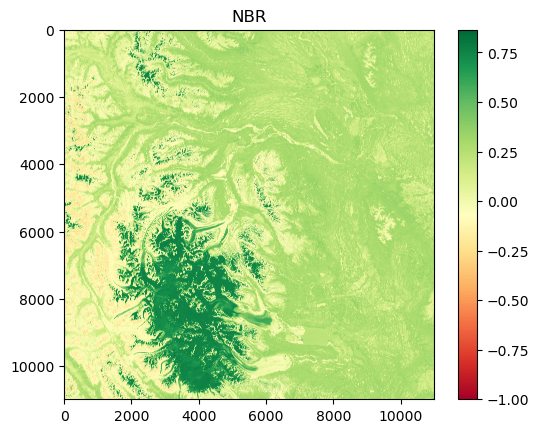

In [9]:
nbr, _, _ = calculate_nbr(B08_band_path, B11_band_path)
plt.title("NBR")
plt.imshow(nbr, cmap='RdYlGn')
plt.colorbar()
plt.show()

The image should now be colored with dark and light greens. A higher NBR corresponds to a greener area and therefore a lower risk of fire. An NBR between 0.25 and -0.25 correponds to dry vegetation and modereate to severe fire risk. < -0.25 is bad news, it means a fire may already be burning!

## Step 3: Applying a Cloud Mask to NBR

Our final step is mask parts of an image that are not relevant to wildfire prediction. Each Sentinel-2 product includes an (Scence Classification Layer) SCL file that classifies every pixel into a number. Each number corresponds to a category, and the ones we will mask out are 3 - cloud shadows, 8 - medium probability cloud, 9 high probability cloud, 10 - thin cirrus cloud. The SCL file should be a .jp2 file located in the 20m band directory.

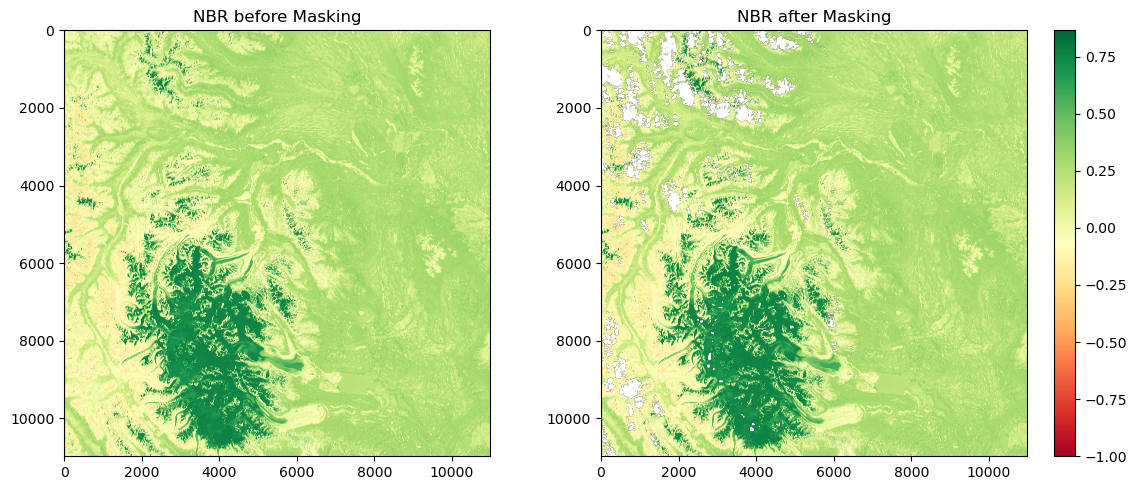

In [ ]:
scl_band_path = os.path.join(band_20m_dir, "path/to/SCL/image.jp2")
masked_nbr, _ = apply_cloud_mask(B08_band_path, B11_band_path, scl_band_path, nir_band.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.set_title("NBR before Masking")
ax2.set_title("NBR after Masking")
im1 = ax1.imshow(nbr, cmap='RdYlGn')
im2 = ax2.imshow(masked_nbr, cmap='RdYlGn')
fig.colorbar(im1, ax=ax2)
plt.tight_layout()
plt.show()


The white patches in the right image are where clouds and shadows have been masked out!

## Downloading your own Sentinel-2 Scene

To download your own Sentinel-2 data, you must create an account on the Copernicus Open Access Hub (https://dataspace.copernicus.eu/). From there, navigate to the Sentinel-2A product and select the **use in browser** feature. Once in the Copernicus browser, select the Search feature, choose the Sentinel-2 data source with MSI and L2A filters included in the dashboard, and navigate to a specific region of Alaska you would like to image. Scroll down on the dashboard, select the time frame and press search. Data packages that agree with the prescribed filters should then populate the dashboard! 